## 1. Import Libraries

In [1]:
import os
import sys
import json
import pandas as pd
from numerapi import NumerAPI
from numerai_tools.scoring import numerai_corr, correlation_contribution
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Add repo root to path so `utils` package is importable.
# This notebook lives at models/v0.2/ — two levels up is the repo root.
_REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if _REPO_ROOT not in sys.path:
    sys.path.insert(0, _REPO_ROOT)

# Styling
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

# Load environment variables from .env file
load_dotenv()


True

In [2]:
# Load the upload keys from environment variables
NAPI_PUBLIC_ID = os.getenv("NAPI_PUBLIC_ID_UPLOAD")
NAPI_SECRET_KEY = os.getenv("NAPI_SECRET_KEY_UPLOAD")

## 2. Initialization & Data Download

In [3]:
from time import time

print(f"\n{'=' * 80}")
print("NUMERAI DATA PIPELINE - INITIALIZATION".center(80))
print(f"{'=' * 80}\n")

napi = NumerAPI(public_id=NAPI_PUBLIC_ID, secret_key=NAPI_SECRET_KEY)
DATA_VERSION = "v5.2"
MAIN_TARGET = "target_ender_20"
DATA_DIR = "../../data"

# Create data directory if it doesn't exist
os.makedirs(DATA_DIR, exist_ok=True)

# Download essential files
files = [
    "train.parquet", 
    "validation.parquet", 
    "live.parquet", 
    "features.json",
    "validation_benchmark_models.parquet",
    "live_benchmark_models.parquet"
]

download_start = time()
for file in files:
    file_path = os.path.join(DATA_DIR, DATA_VERSION, file)
    
    if os.path.exists(file_path):
        print(f"✓ {file:<40} [CACHED]")
    else:
        print(f"⬇ {file:<40} [DOWNLOADING...]", end="", flush=True)
        os.makedirs(os.path.dirname(file_path), exist_ok=True)
        napi.download_dataset(f"{DATA_VERSION}/{file}", dest_path=file_path)
        print(f"\r✓ {file:<40} [DOWNLOADED]")

download_time = time() - download_start
print(f"\n⏱ Total download time: {download_time:.2f}s\n")

# Load Feature Metadata
feature_metadata = json.load(open(os.path.join(DATA_DIR, DATA_VERSION, "features.json")))
feature_set = feature_metadata["feature_sets"]["small"]  # Use 'small' for faster iteration

print(f"📋 Feature Set: 'small' ({len(feature_set)} features)")
print(f"{'=' * 80}\n")


                     NUMERAI DATA PIPELINE - INITIALIZATION                     

✓ train.parquet                            [CACHED]
✓ validation.parquet                       [CACHED]
✓ live.parquet                             [CACHED]
✓ features.json                            [CACHED]
✓ validation_benchmark_models.parquet      [CACHED]
✓ live_benchmark_models.parquet            [CACHED]

⏱ Total download time: 0.00s

📋 Feature Set: 'small' (42 features)



## 3. Data Loading & Pre-processing

In [4]:
print(f"\n{'=' * 80}")
print("DATA LOADING & PREPROCESSING".center(80))
print(f"{'=' * 80}\n")

load_start = time()

# Load Training Data
MAIN_TARGET = "target"

print(f"📥 Loading training data...", end="", flush=True)
train = pd.read_parquet(
    os.path.join(DATA_DIR, DATA_VERSION, "train.parquet"), 
    columns=["era", MAIN_TARGET] + feature_set
)
print(f"\r✓ Training data loaded: {len(train):,} rows")

# Load Validation Data & Benchmarks
print(f"📥 Loading validation data...", end="", flush=True)
validation = pd.read_parquet(
    os.path.join(DATA_DIR, DATA_VERSION, "validation.parquet"), 
    columns=["era", MAIN_TARGET] + feature_set
)
val_benchmarks = pd.read_parquet(
    os.path.join(DATA_DIR, DATA_VERSION, "validation_benchmark_models.parquet")
)
print(f"\r✓ Validation data loaded: {len(validation):,} rows")

# Load Live Data & Benchmarks
print(f"📥 Loading live data...", end="", flush=True)
live = pd.read_parquet(
    os.path.join(DATA_DIR, DATA_VERSION, "live.parquet"), 
    columns=["era"] + feature_set
)
live_benchmarks = pd.read_parquet(
    os.path.join(DATA_DIR, DATA_VERSION, "live_benchmark_models.parquet")
)
print(f"\r✓ Live data loaded: {len(live):,} rows")

# Apply 4-era Embargo to prevent leakage
last_train_era = int(train["era"].unique()[-1])
eras_to_embargo = [str(era).zfill(4) for era in range(last_train_era + 1, last_train_era + 5)]
validation = validation[~validation["era"].isin(eras_to_embargo)]

load_time = time() - load_start

print(f"\n⚠️  Applied 4-era embargo: Removed {len(eras_to_embargo)} eras from validation")
print(f"📊 Training eras: {train['era'].nunique()}")
print(f"📊 Validation eras: {validation['era'].nunique()}")
print(f"📊 Live eras: {live['era'].nunique()}")
print(f"\n⏱ Total load time: {load_time:.2f}s")
print(f"{'=' * 80}\n")


                          DATA LOADING & PREPROCESSING                          

✓ Training data loaded: 2,746,268 rows
✓ Validation data loaded: 3,943,998 rows
✓ Live data loaded: 7,128 rows

⚠️  Applied 4-era embargo: Removed 4 eras from validation
📊 Training eras: 574
📊 Validation eras: 630
📊 Live eras: 1

⏱ Total load time: 13.03s



In [5]:
# Print era range of training and validation sets
print(f"(1) Training Era Range: {train['era'].min()} to {train['era'].max()}")
print(f"(2) Validation Era Range: {validation['era'].min()} to {validation['era'].max()}\n")

(1) Training Era Range: 0001 to 0574
(2) Validation Era Range: 0579 to 1208



In [6]:
# Print all target columns in the dataset
target_columns = [col for col in train.columns if col.startswith("target_")]
for t in target_columns:
    print(f"- {t}")

## 4. Prediction Engine

Implement your ML model logic here.

In [7]:
import pandas as pd
import numpy as np
import xgboost as xgb
from numerai_tools.scoring import numerai_corr
from sklearn.metrics import mean_squared_error

print("XGB Version:", xgb.__version__)


def prediction_engine(train_df, val_df, live_df, features):

    print(f"\n{'=' * 80}")
    print("XGBOOST MODEL TRAINING".center(80))
    print(f"{'=' * 80}\n")

    # Drop rows where the target is NaN (common in Numerai validation sets)
    train_clean = train_df[features + [MAIN_TARGET]].dropna(subset=[MAIN_TARGET])
    val_clean   = val_df[features + [MAIN_TARGET]].dropna(subset=[MAIN_TARGET])
    print(f">> Training rows after dropna : {len(train_clean):,} (diff {len(train_df) - len(train_clean):,})")
    print(f">> Validation rows after dropna: {len(val_clean):,} (diff {len(val_df) - len(val_clean):,})\n")

    # --- Hyperparameters ---
    params = {
        "objective": "reg:squarederror",
        "n_estimators": 2000,
        "max_depth": 6,
        "learning_rate": 0.01,
        "subsample": 0.8,
        "colsample_bytree": 0.1,
        "colsample_bylevel": 0.8,
        "reg_lambda": 0.1,
        "eval_metric": "rmse",
        "random_state": 42,
        "early_stopping_rounds": 50,   # XGBoost 3.x: constructor param
    }

    print("Hyperparameters:")
    for k, v in params.items():
        print(f"  {k}: {v}")
    print()

    model = xgb.XGBRegressor(**params)

    # --- Fit with early stopping ---
    model.fit(
        train_clean[features],
        train_clean[MAIN_TARGET],
        eval_set=[
            (train_clean[features], train_clean[MAIN_TARGET]),
            (val_clean[features],   val_clean[MAIN_TARGET]),
        ],
        verbose=200,
    )

    print(f"\n✅ Training complete.")
    print(f"   Best iteration : {model.best_iteration}")
    print(f"   Best val RMSE  : {model.best_score:.6f}")

    # --- Evaluation ---
    y_val_pred_raw = model.predict(val_clean[features])
    rmse = np.sqrt(mean_squared_error(val_clean[MAIN_TARGET], y_val_pred_raw))
    r2   = model.score(val_clean[features], val_clean[MAIN_TARGET])
    print(f"   Val RMSE       : {rmse:.6f}")
    print(f"   Val R²         : {r2:.6f}")

    # --- Rank-transform all rows (including those with NaN targets for val/live) ---
    val_preds  = pd.Series(model.predict(val_df[features])).rank(pct=True).values
    live_preds = pd.Series(model.predict(live_df[features])).rank(pct=True).values

    return val_preds, live_preds, model


XGB Version: 3.2.0


In [8]:
# Execute Engine
val_predictions, live_predictions, trained_model = prediction_engine(train, validation, live, feature_set)


                             XGBOOST MODEL TRAINING                             

>> Training rows after dropna : 2,746,268 (diff 0)
>> Validation rows after dropna: 3,886,183 (diff 35,124)

Hyperparameters:
  objective: reg:squarederror
  n_estimators: 2000
  max_depth: 6
  learning_rate: 0.01
  subsample: 0.8
  colsample_bytree: 0.1
  colsample_bylevel: 0.8
  reg_lambda: 0.1
  eval_metric: rmse
  random_state: 42
  early_stopping_rounds: 50

[0]	validation_0-rmse:0.22369	validation_1-rmse:0.22367
[200]	validation_0-rmse:0.22362	validation_1-rmse:0.22366
[400]	validation_0-rmse:0.22356	validation_1-rmse:0.22366
[600]	validation_0-rmse:0.22350	validation_1-rmse:0.22365
[684]	validation_0-rmse:0.22348	validation_1-rmse:0.22365

✅ Training complete.
   Best iteration : 634
   Best val RMSE  : 0.223654
   Val RMSE       : 0.223654
   Val R²         : 0.000182


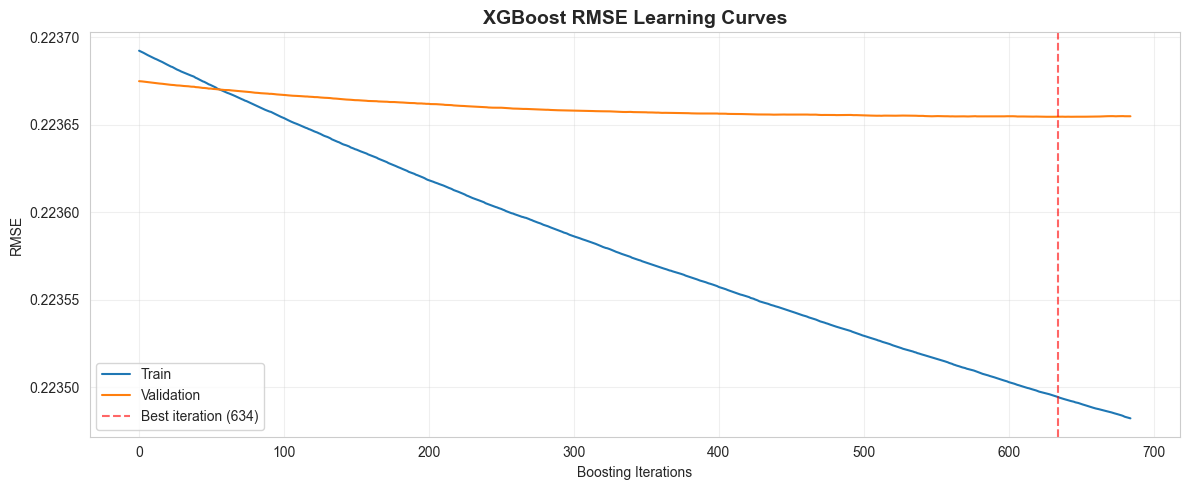

In [9]:
# --- Learning Curves ---
results = trained_model.evals_result()
epochs  = len(results["validation_0"]["rmse"])
x_axis  = range(0, epochs)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(x_axis, results["validation_0"]["rmse"], label="Train")
ax.plot(x_axis, results["validation_1"]["rmse"], label="Validation")
ax.axvline(x=trained_model.best_iteration, color="red", linestyle="--",
           alpha=0.6, label=f"Best iteration ({trained_model.best_iteration})")
ax.set_title("XGBoost RMSE Learning Curves", fontweight="bold", fontsize=14)
ax.set_xlabel("Boosting Iterations")
ax.set_ylabel("RMSE")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 5. Generate Predictions

In [10]:
# Assign to dataframes for scoring
validation["prediction"] = val_predictions
live["prediction"] = live_predictions

print(f"\n{'=' * 80}")
print("PREDICTIONS SUMMARY".center(80))
print(f"{'=' * 80}")
print(f"Validation predictions: {len(val_predictions):,}")
print(f"Live predictions: {len(live_predictions):,}")
print(f"Validation range: [{val_predictions.min():.6f}, {val_predictions.max():.6f}]")
print(f"Live range: [{live_predictions.min():.6f}, {live_predictions.max():.6f}]")
print(f"{'=' * 80}\n")


                              PREDICTIONS SUMMARY                               
Validation predictions: 3,921,307
Live predictions: 7,128
Validation range: [0.000000, 1.000000]
Live range: [0.000140, 1.000000]



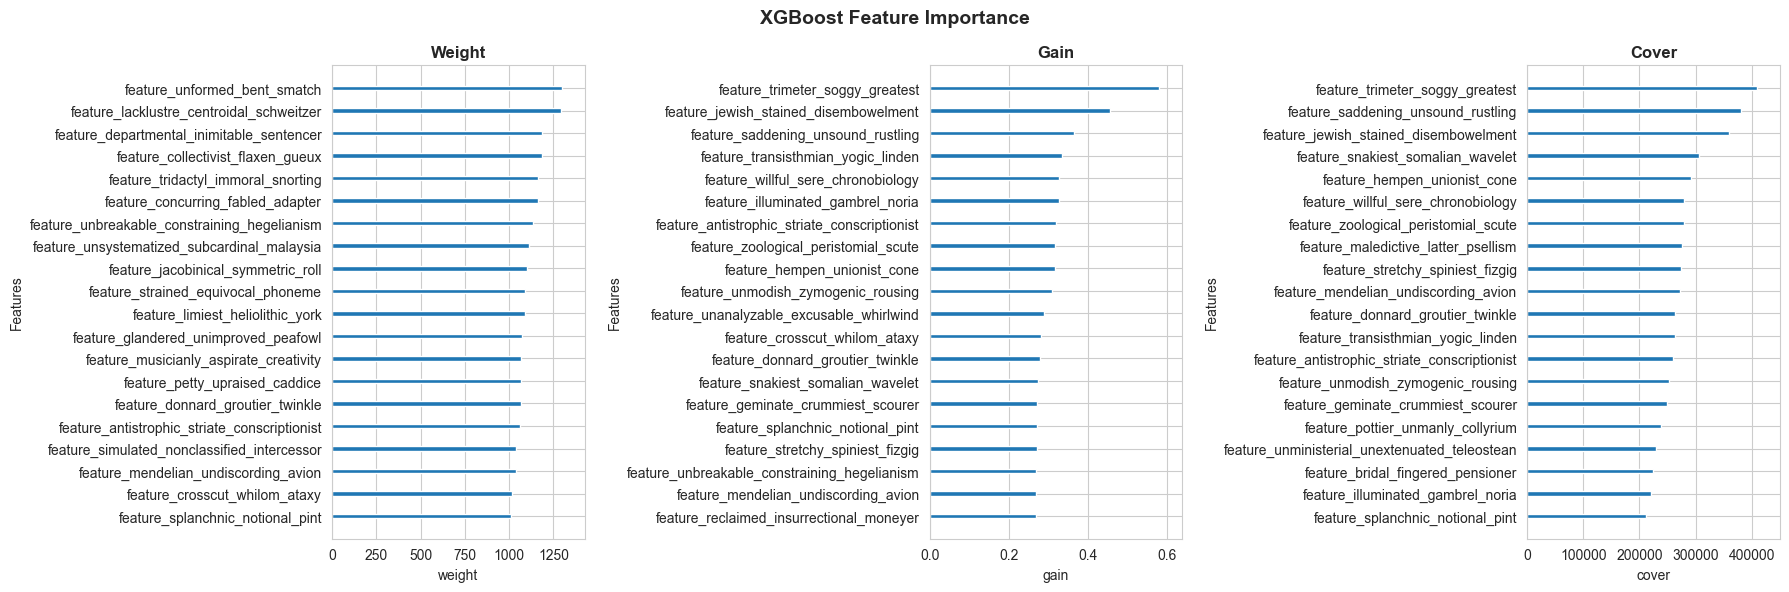

In [11]:
from sklearn.inspection import permutation_importance

# --- Built-in Feature Importance (gain) ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("XGBoost Feature Importance", fontweight="bold", fontsize=14)

for ax, imp_type in zip(axes, ["weight", "gain", "cover"]):
    xgb.plot_importance(
        trained_model,
        importance_type=imp_type,
        show_values=False,
        xlabel=imp_type,
        ax=ax,
        max_num_features=20,
    )
    ax.set_title(imp_type.capitalize(), fontweight="bold")

plt.tight_layout()
plt.show()


## 6. Metrics & Similarity Analysis

In [12]:
from pathlib import Path
from utils.metrics import calculate_metrics
from utils.visualization import display_metrics_table, plot_performance_diagnostics
from utils.model_benchmark import record_model_metrics, compare_top_models_with_current


## 7. Display Results

In [13]:
# Calculate comprehensive metrics
metrics, per_era_df = calculate_metrics(df_validation=validation, 
                                        benchmarks=val_benchmarks,
                                        features=feature_set,
                                        target_col=MAIN_TARGET)


                        KEY PERFORMANCE METRICS vs GOALS                        



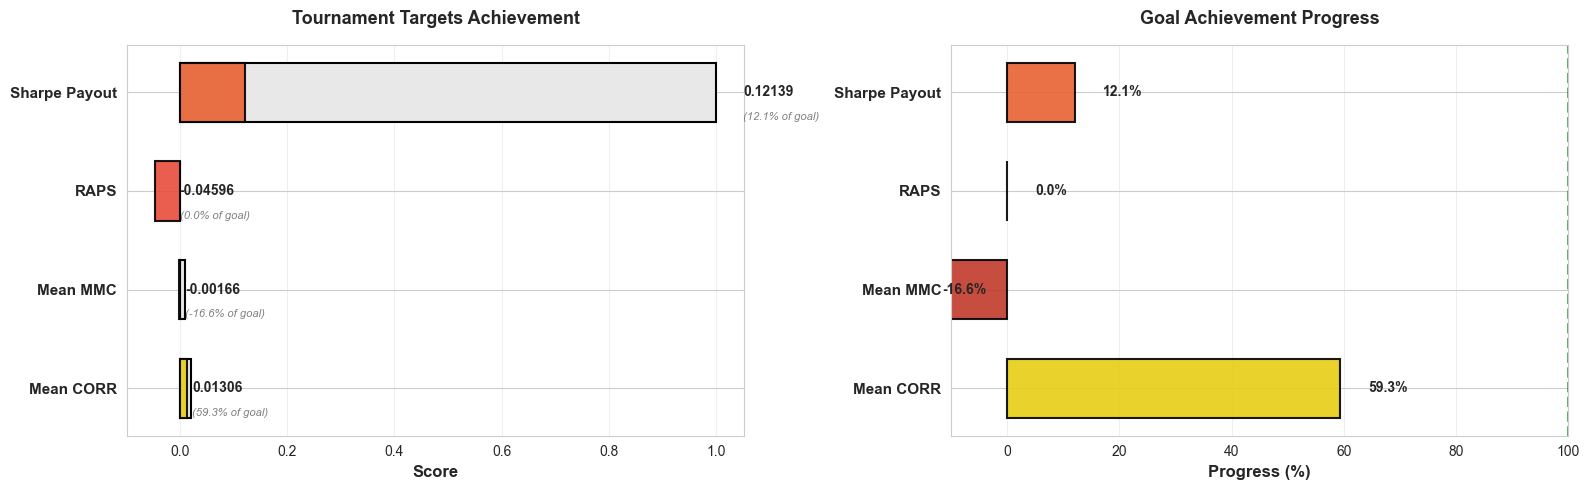

Category,Metric,Value,Goal,Status,Note
Payout,RAPS,-0.0460,+0,🔴 BELOW,Risk-adjusted payout proxy with drawdown and tail-risk penalties
Payout,Mean MMC (BMC Proxy),-0.00166,+0.01,🔴 BELOW,Uniqueness vs benchmark (2× NMR multiplier)
Payout,Mean CORR,+0.01306,+0.022,🟠 LAGGING,Official Numerai correlation score (0.5× multiplier)
Risk,Sharpe Ratio,+0.9108,+1,🟡 CLOSE,Risk-adjusted return consistency
Risk,Payout Sharpe,+0.1214,+1,🔴 BELOW,Sharpe ratio of payout proxy (0.5×CORR + 2×MMC)
Risk,MMC Volatility,0.01032,—,—,Standard deviation of era-by-era MMC
Risk,Max Drawdown,-0.09455,-0.05,🟡 CLOSE,Worst sustained CORR cumulative loss
Quality,Mean FNC,+0.00892,+0,✅ MET,CORR after removing linear feature exposure
Quality,Win Rate,80.5%,+0.55,✅ MET,Fraction of eras with positive CORR
Uniqueness,P95 Max Feature Exposure,0.4069,+0.2,🔴 EXCEEDED,95th percentile of strongest single-feature correlation


In [14]:
# Display professional metrics table
display_metrics_table(metrics, extended=True)

## 7.1 Benchmark Against Previous Models

In [15]:
notebook_name = Path(globals().get("__vsc_ipynb_file__", "finance_arena_v0.2.ipynb")).stem
history_df, current_run = record_model_metrics(
    metrics=metrics,
    model_name=notebook_name,
    notebook_name=notebook_name,
)

leaderboard_df, is_top = compare_top_models_with_current(
    current_run_id=current_run["run_id"],
    top_n=3,
    show_message=True,
 )

print("\nMODEL LEADERBOARD (Top 3 + Current)")
display_df = leaderboard_df.copy()
for col, digits in {"mean_mmc": 6, "mean_corr": 6, "raps": 4, "sharpe_payout": 4}.items():
    display_df[col] = display_df[col].astype(float).round(digits)
display(display_df)


MODEL LEADERBOARD (Top 3 + Current)


,rank,model_name,run_id,mean_mmc,mean_corr,raps,sharpe_payout,timestamp_utc,is_current
0,1,lgbm_ensemble_v0.3,52f4b2df,0.000512,0.011083,0.1332,0.2416,2026-03-07 16:38:46,False
1,2,1_hello_numerai_modified,c7fae6f9,-0.000914,0.012383,0.0774,0.1610,2026-03-01 21:40:09,False
2,3,finance_arena_v0.1,2c663abc,-0.001063,0.012799,0.0383,0.1598,2026-03-01 22:05:13,False
3,6,finance_arena_v0.2,586dc5ef,-0.001657,0.013056,-0.0460,0.1214,2026-03-01 22:10:30,True


In [16]:
# Visualize performance diagnostics
#plot_performance_diagnostics(per_era_df, metrics)

# 8. Export PKL model

In [17]:
assert False

AssertionError: 

In [18]:
# Export model to pkl file named after this notebook
from pathlib import Path
import cloudpickle
import pandas as pd

# Define the predict function as required by Numerai
def predict(live_features: pd.DataFrame, live_benchmark_models: pd.DataFrame = None) -> pd.DataFrame:
    # Ensure raw predictions are rank-transformed and match the validation/live format
    raw_preds = trained_model.predict(live_features[feature_set])
    ranks = pd.Series(raw_preds, index=live_features.index).rank(pct=True)
    return pd.DataFrame(ranks, columns=["prediction"])

notebook_file = (
    globals().get("__vsc_ipynb_file__")      # VS Code notebooks
    or os.environ.get("JPY_SESSION_NAME")    # JupyterLab/Notebook session name
)

if not notebook_file:
    # Fallback if detection fails
    notebook_file = "finance_arena_v0.2.ipynb"

model_filename = f"{Path(notebook_file).stem}.pkl"
with open(model_filename, "wb") as f:
    cloudpickle.dump(predict, f)

print(f"Saved model as function using cloudpickle: {model_filename}")

Saved model as function using cloudpickle: finance_arena_v0.2.pkl


-----------
# 9. Production Stage

In [19]:
print("\n" + "="*80)
print("PRODUCTION STAGE: TRAINING ON ALL AVAILABLE DATA")
print("="*80 + "\n")

# 1. Concatenate the Train and Validation datasets
print("Merging train and validation datasets for final production model...")
# Ensure we keep the target and features
columns_to_keep = ["era", MAIN_TARGET] + feature_set

# WE MUST RELOAD VALIDATION: The `validation` df in memory had 4 eras stripped out via the embargo!
print("Reloading raw validation set to recover previously embargoed eras...")
full_validation = pd.read_parquet(
    os.path.join(DATA_DIR, DATA_VERSION, "validation.parquet"), 
    columns=columns_to_keep
)

full_data = pd.concat([
    train[columns_to_keep], 
    full_validation[columns_to_keep]
], ignore_index=True)

print(f"Full production dataset shape: {full_data.shape}")

# 2. Train on the full dataset without early stopping
print(f"\n--- Production Training on {MAIN_TARGET} ---")
train_clean = full_data.dropna(subset=[MAIN_TARGET])

# Optimal number of trees from our previous early stopping run
best_iters = getattr(trained_model, "best_iteration", 2000)
print(f"Using n_estimators: {best_iters} (best iteration from previous phase)")

prod_params = {
    "objective": "reg:squarederror",
    "n_estimators": best_iters,   
    "max_depth": 6,
    "learning_rate": 0.01,
    "subsample": 0.8,
    "colsample_bytree": 0.1,
    "colsample_bylevel": 0.8,
    "reg_lambda": 0.1,
    "eval_metric": "rmse",
    "random_state": 42
}

prod_model = xgb.XGBRegressor(**prod_params)
prod_model.fit(
    train_clean[feature_set],
    train_clean[MAIN_TARGET],
    verbose=200
)

print("\n✅ Production model fully trained on all available data.")


PRODUCTION STAGE: TRAINING ON ALL AVAILABLE DATA

Merging train and validation datasets for final production model...
Reloading raw validation set to recover previously embargoed eras...
Full production dataset shape: (6690266, 44)

--- Production Training on target ---
Using n_estimators: 634 (best iteration from previous phase)

✅ Production model fully trained on all available data.


In [20]:
# 3. Save Production Model Wrapper (for cloudpickle upload)
import cloudpickle

# Define the prediction function using the production model
def predict(live_features: pd.DataFrame, live_benchmark_models: pd.DataFrame = None) -> pd.DataFrame:
    # Ensure raw predictions are rank-transformed and match the validation/live format
    raw_preds = prod_model.predict(live_features[feature_set])
    ranks = pd.Series(raw_preds, index=live_features.index).rank(pct=True)
    return pd.DataFrame(ranks, columns=["prediction"])

model_filename = "finance_arena_v0_2_1.pkl"
with open(model_filename, "wb") as f:
    cloudpickle.dump(predict, f)

print(f"🔥 Production Pipeline Complete. Model exported to {model_filename}")

🔥 Production Pipeline Complete. Model exported to finance_arena_v0_2_1.pkl


In [21]:
# IDEA : use mmc or corr as the validation metric instead of rmse, since that's what Numerai actually scores on. This would require implementing a custom callback for XGBoost to calculate MMC/corr on the validation set at each iteration and use that for early stopping instead of rmse.
# IDEA #2 : implement a custom training loop with manual early stopping based on MMC/corr instead of relying on XGBoost's built-in early stopping which only supports standard metrics like rmse. This would allow us to directly optimize for the metric that Numerai uses for scoring.
# IDEA #3 : Make an ensemble of XGBoost models trained on different targets or with different seeds to improve generalization and stability of predictions. This would involve training multiple XGBoost models and averaging their rank-transformed predictions for the final output.